[cell] SPACE-HOP notebook C : test (val + real)
[setup] device=cuda ckpt=/kaggle/input/notebooks/wolgwang/spacehop-finetune/shop/spacehop_best.pth K=2048 img=224
[setup] images: /kaggle/input/datasets/wolgwang/speedsplit/speed/images/trainval OK
[setup] json: /kaggle/input/datasets/wolgwang/speedsplit/speed/train.json OK
[data] /kaggle/input/datasets/wolgwang/speedsplit/speed/train.json: 9600 images
[setup] val=1920 (train part 7680 skipped for test)
[data] /kaggle/input/datasets/wolgwang/speedsplit/speed/real.json: 5 images
[setup] real=5
[setup] Hopf anchors K=2048 (256x8)
Downloading: "https://download.pytorch.org/models/vit_b_16_swag-9ac1b537.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16_swag-9ac1b537.pth


100%|██████████| 331M/331M [00:03<00:00, 101MB/s]  


[test] N val=1920 real=5
Results Summary:
+----------------------+------------------------------+------------------------------+
| Metric               | SPEED val split              | SPEED real test              |
+----------------------+------------------------------+------------------------------+
| Mean ET (m)          | [-0.001 -0.002 -0.028]       | [-0.043 -0.079 0.011]        |
| Mean ET mag (m)      | 0.2734                       | 0.1586                       |
| Median ET mag (m)    | 0.1944                       | 0.1561                       |
| Mean ER (deg)        | 3.4281                       | 8.0738                       |
| Median ER (deg)      | 2.9924                       | 7.5561                       |
+----------------------+------------------------------+------------------------------+
[plot] saved /kaggle/working/shop/test_hist_val.png


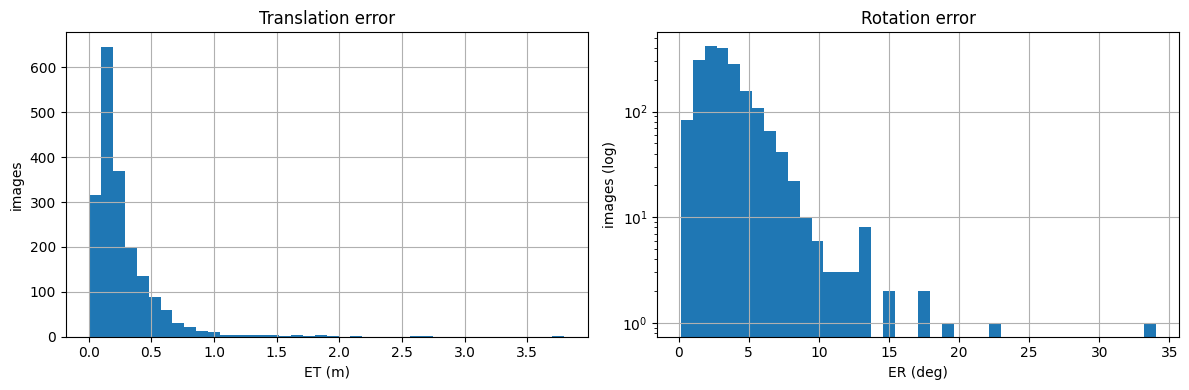

[plot] saved /kaggle/working/shop/test_qual_worst.png


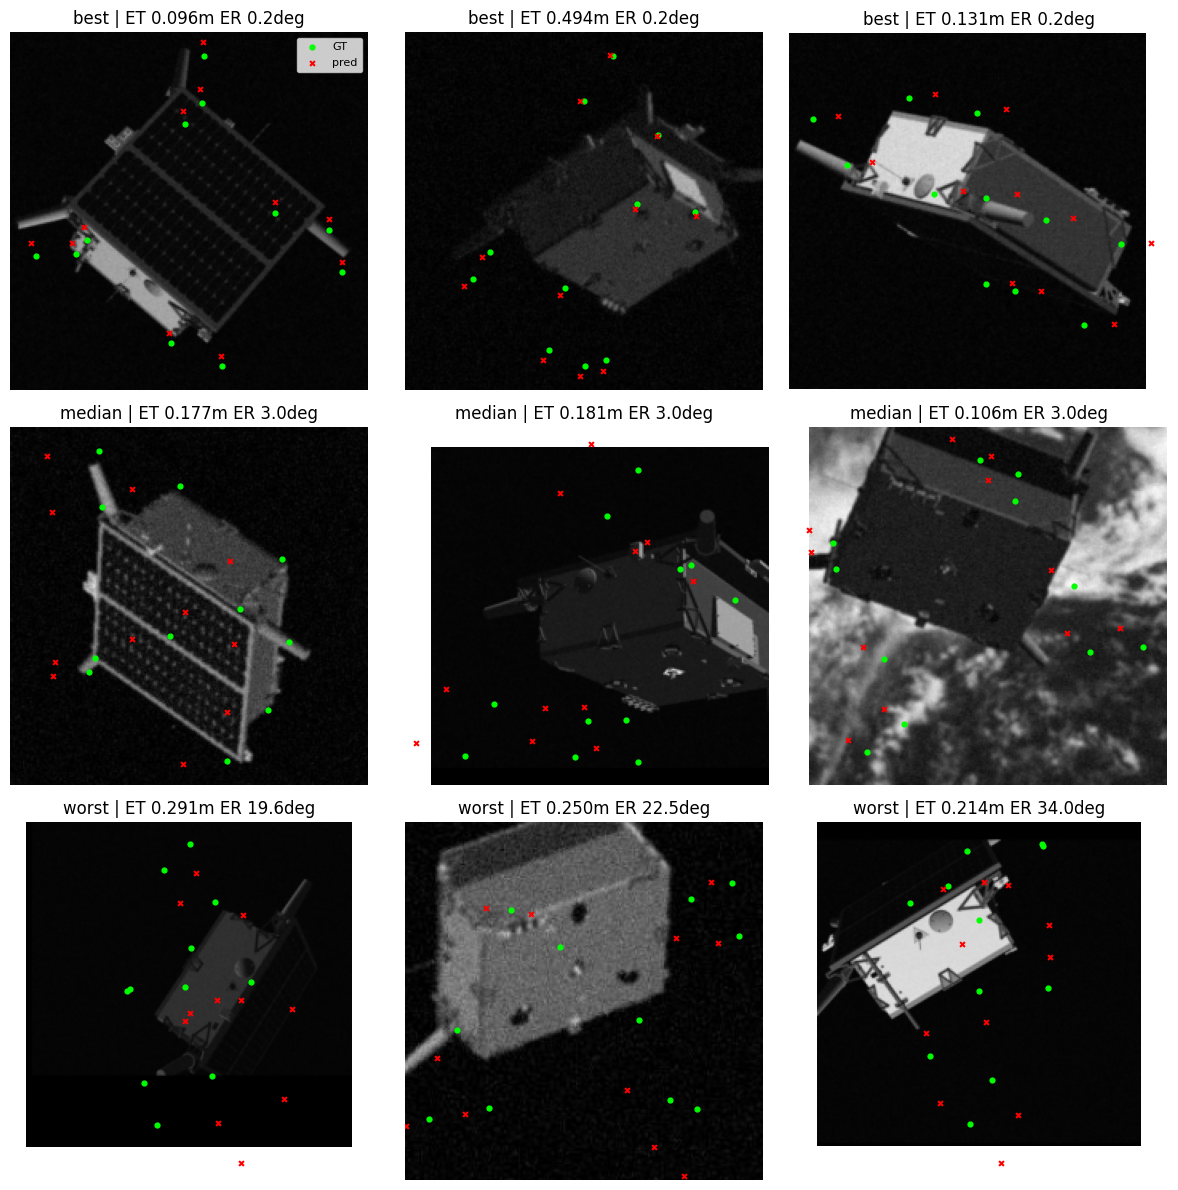

[plot] saved /kaggle/working/shop/test_hist_real.png


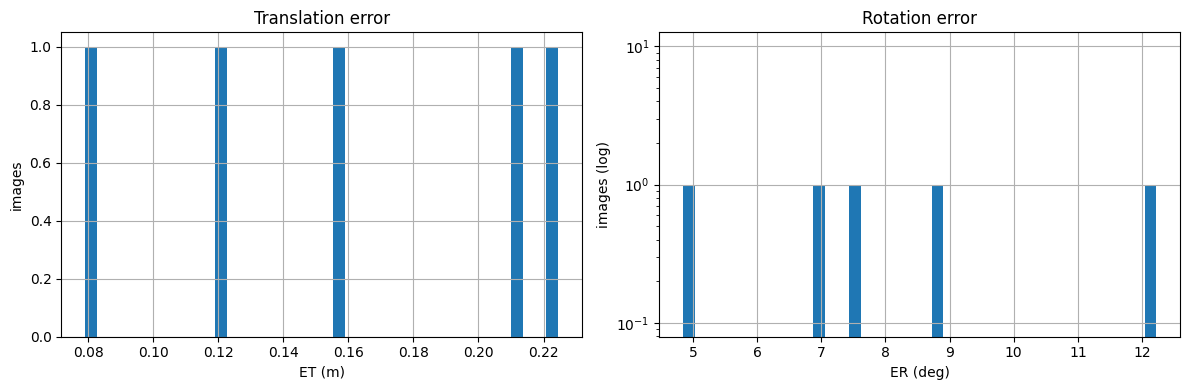

[plot] saved /kaggle/working/shop/test_qual_worst.png


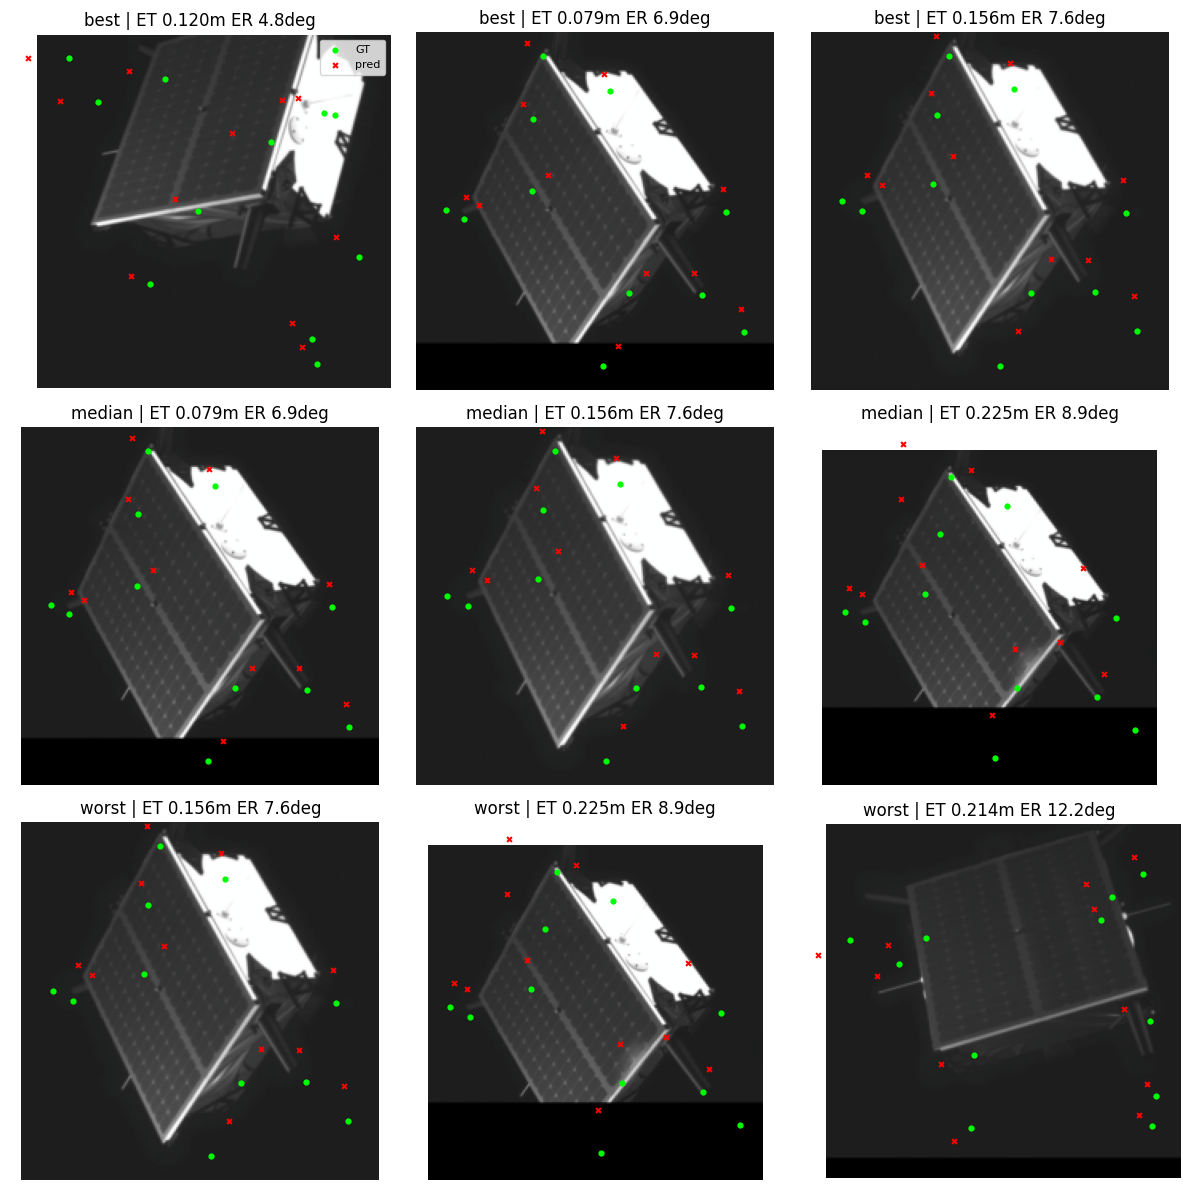

[done] test figures in /kaggle/working/shop/


In [1]:
#!/usr/bin/env python3
"""SPACE-HOP notebook C — test on SPEED (paste into ONE Kaggle cell, Run).

Paper: SPACE-HOP: Spacecraft 6-DoF Pose Estimation using Embedding-Predictive
Pretraining and Hopf Map (CVPR 2026 submission #36, confidential review copy).

What this file implements (paper Sec. -> code):
  Sec 4.1 (Eq.20-21) ET (m) / ER (deg) on the val split, error histograms
                    (paper Fig.4 style) + GT-vs-pred keypoint overlays.

Scope deltas vs paper (SPEED-only, Kaggle-friendly):
  - Paper trains on SPEED+ synthetic (59,960 imgs). Here: SPEED trainval split
    (same 80/20 seed-42 protocol as fastpose/fastpose.ipynb) + eval on val/real.
  - Paper trains ViT from scratch. Default here: ImageNet init (torchvision
    ViT-B/16) for Kaggle-time convergence; set INIT = "random" for paper-faithful.
  - Anchor count K = HOPF_N x HOPF_M is a hyperparam (paper omits it).
    Default 256x8=2048; smoke uses 64x4=256.
  - Rotation target is the ABSOLUTE camera-frame rotation (SPEED labels).
    fastpose.ipynb instead regresses "apparent" (translation-compensated)
    rotation; we skip that compensation (paper has no such step).

KAGGLE CELL HOW-TO (paste this ENTIRE file into ONE notebook cell, then Run):
  Notebook C (this file): add datasets speedsplit + mat-file + notebook B's saved
    output (spacehop_best.pth is auto-found), CPU or GPU, Run. Uses the same
    seed-42 split as training, so numbers compare directly. Tests both the
    synthetic val split and the real set (like fastposetest), when present.
  Prints the Results Summary table plus histograms and overlays per split.

Outputs in OUT_DIR: test_hist_{val,real}.png, test_qual_{val,real}.png (also shown inline).
"""
from __future__ import annotations

from types import SimpleNamespace
import copy
import json
import math
import os
import random
import time

import numpy as np

try:
    import torch
    import torch.nn.functional as F
    from torch import nn
    from torch.utils.data import DataLoader, Dataset
    from torchvision import models, transforms
except ImportError as e:  # pragma: no cover - Kaggle has torch preinstalled
    raise SystemExit(f"torch/torchvision required: {e}")

try:
    from PIL import Image, ImageOps
except ImportError as e:
    raise SystemExit(f"pillow required: {e}")

try:
    from scipy.io import loadmat
except ImportError:  # keypoints .mat loading needs scipy; fall back to .txt
    loadmat = None

try:
    import albumentations as A
    _HAS_ALB = True
except ImportError:
    _HAS_ALB = False

try:
    import tqdm
    _HAS_TQDM = True
except ImportError:
    _HAS_TQDM = False

EPS = 1e-8

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# ----------------------------------------------------------------------------
# *** EDIT ME *** — settings (plain variables, like fastpose.ipynb)
# ----------------------------------------------------------------------------
OUT_DIR = "/kaggle/working/shop"
CKPT = None  # None = auto-find spacehop_best.pth (notebook B output or local OUT_DIR)
SUBSET = None  # must match the training split for comparable numbers (None = full)
BATCH_SIZE = 64
INIT = "imagenet"  # must match notebook A (architecture only; weights come from CKPT)
IMG_SIZE = 224  # overridden by CKPT when present
WORKERS = 2
SEED = 42
HOPF_N = 256
HOPF_M = 8        # fallback only; the anchor grid is rebuilt from CKPT when present
N_SHOW = 9        # qualitative overlays: 3 best + 3 median + 3 worst by ER
# optional path overrides (None = auto-detect mounted Kaggle datasets):
IMAGES_DIR = None
TRAIN_JSON = None
MAT_FILE = None
CAMERA_JSON = None
REAL_IMAGES = None
REAL_JSON = None  # None = auto-detect the real set (speedsplit real.json + images)

# ----------------------------------------------------------------------------
# Config / paths
# ----------------------------------------------------------------------------

KAGGLE_IMG_CANDIDATES = [
    "/kaggle/input/speedsplit/speed/images/trainval",
    "/kaggle/input/speed/speed/images/train",
]
KAGGLE_JSON_CANDIDATES = [
    "/kaggle/input/speedsplit/speed/train.json",
    "/kaggle/input/speed/speed/train.json",
]
KAGGLE_MAT = "/kaggle/input/mat-file/tangoPoints.mat"
KAGGLE_CAM = "/kaggle/input/mat-file/camera.json"
LOCAL_DEFAULTS = ("data/speed/images/train", "data/speed/labels/train.json",
                  "data/speed/tango_points.mat", "data/speed/camera.json")


def _discover_kaggle(root="/kaggle/input"):
    """Find SPEED files by walking mounted inputs (slug/layout agnostic).

    Dataset slugs vary (e.g. 'SPEEDsplit' vs 'speedsplit') and subfolders may
    differ, so instead of guessing absolute paths we search for:
      train.json, camera.json, *tango*.mat, and the jpg-heaviest train dir.
    """
    out = {"train_json": None, "images": None, "mat": None, "cam": None,
           "real_json": None, "real_images": None}
    if not os.path.isdir(root):
        return out
    best, best_real = (0, None), (0, None)
    for dp, _dn, fn in os.walk(root):
        for f in fn:
            fl = f.lower()
            p = os.path.join(dp, f)
            if fl == "train.json" and out["train_json"] is None:
                out["train_json"] = p
            elif fl == "real.json" and out["real_json"] is None:
                out["real_json"] = p
            elif fl == "camera.json" and out["cam"] is None:
                out["cam"] = p
            elif fl.endswith(".mat") and "tango" in fl and out["mat"] is None:
                out["mat"] = p
        n_jpg = sum(1 for f in fn if f.lower().endswith((".jpg", ".jpeg", ".png")))
        low = dp.lower()
        if n_jpg > best[0] and ("train" in low or "image" in low):
            best = (n_jpg, dp)
        if "real" in low and n_jpg > best_real[0]:
            best_real = (n_jpg, dp)
    if out["mat"] is None:  # fallback: any .mat
        for dp, _dn, fn in os.walk(root):
            for f in fn:
                if f.lower().endswith(".mat"):
                    out["mat"] = os.path.join(dp, f)
                    break
            if out["mat"] is not None:
                break
    out["images"] = best[1]
    out["real_images"] = best_real[1]
    return out


def resolve_data(args):
    """Explicit path overrides first, then discovered Kaggle paths, then guesses."""
    disc = _discover_kaggle()

    def pick(explicit, discovered, cands, local):
        if explicit and os.path.exists(explicit):
            return explicit
        if discovered and os.path.exists(discovered):
            return discovered
        for c in cands:
            if c and os.path.exists(c):
                return c
        return local

    images = pick(args.images_dir, disc["images"], KAGGLE_IMG_CANDIDATES, LOCAL_DEFAULTS[0])
    js = pick(args.train_json, disc["train_json"], KAGGLE_JSON_CANDIDATES, LOCAL_DEFAULTS[1])
    mat = pick(args.mat_file, disc["mat"], [KAGGLE_MAT], LOCAL_DEFAULTS[2])
    cam = pick(args.camera_json, disc["cam"], [KAGGLE_CAM], LOCAL_DEFAULTS[3])
    real_images = pick(args.real_images, disc["real_images"], [], None)
    real_json = pick(args.real_json, disc["real_json"], [], None)
    return images, js, mat, cam, real_images, real_json


def _require_inputs(images, js):
    """Fail fast with a map of /kaggle/input when required files are missing."""
    for label, p in [("images", images), ("json", js)]:
        print(f"[setup] {label}: {p} {'OK' if os.path.exists(p) else 'MISSING'}", flush=True)
    missing = [p for p in (images, js) if not os.path.exists(p)]
    if missing:
        print("[setup] /kaggle/input map (top levels):")
        for dp, dn, fn in os.walk("/kaggle/input"):
            depth = dp.replace("/kaggle/input", "").count(os.sep)
            if depth > 2:
                dn[:] = []
                continue
            print(f"  {dp}: dirs={dn[:10]} files={fn[:10]}")
            if depth >= 2:
                dn[:] = []
        raise SystemExit(f"missing required inputs: {missing}")


def _find_test_ckpt():
    """notebook B's spacehop_best.pth: local OUT_DIR first, then attached inputs."""
    for root in ("/kaggle/working", "/kaggle/input"):
        for dp, _dn, fn in os.walk(root):
            if "spacehop_best.pth" in fn:
                return os.path.join(dp, "spacehop_best.pth")
    return None


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# ----------------------------------------------------------------------------
# Geometry: quaternions (scalar-first, SPEED convention), axis-angle, Hopf grid
# ----------------------------------------------------------------------------

def quat2dcm_np(q):
    """Direction cosine matrix from scalar-first quaternion (numpy, for projection)."""
    q = np.asarray(q, dtype=np.float64)
    q = q / (np.linalg.norm(q) + 1e-12)
    w, x, y, z = q
    return np.array([
        [1 - 2 * (y * y + z * z), 2 * (x * y - z * w), 2 * (x * z + y * w)],
        [2 * (x * y + z * w), 1 - 2 * (x * x + z * z), 2 * (y * z - x * w)],
        [2 * (x * z - y * w), 2 * (y * z + x * w), 1 - 2 * (x * x + y * y)],
    ], dtype=np.float64)


def project_keypoints_np(q, t, camera_matrix, dist_coeffs, keypoints3d):
    """Project 11x3 body points to 2xN pixels (Brown distortion, cf. fastpose)."""
    kp = np.asarray(keypoints3d, dtype=np.float64)
    if kp.shape[0] != 3 and kp.shape[1] == 3:
        kp = kp.T  # -> 3xN
    kp_h = np.vstack([kp, np.ones((1, kp.shape[1]))])
    pose = np.hstack([quat2dcm_np(q).T, np.asarray(t, dtype=np.float64).reshape(3, 1)])
    xyz = pose @ kp_h
    x0, y0 = xyz[0] / xyz[2], xyz[1] / xyz[2]
    dc = np.asarray(dist_coeffs, dtype=np.float64).reshape(-1)
    k1, k2, p1, p2, k3 = (list(dc) + [0] * 5)[:5]
    r2 = x0 * x0 + y0 * y0
    cdist = 1 + k1 * r2 + k2 * r2 * r2 + k3 * r2 * r2 * r2
    x = x0 * cdist + p1 * 2 * x0 * y0 + p2 * (r2 + 2 * x0 * x0)
    y = y0 * cdist + p1 * (r2 + 2 * y0 * y0) + p2 * 2 * x0 * y0
    cm = np.asarray(camera_matrix, dtype=np.float64)
    return np.vstack([cm[0, 0] * x + cm[0, 2], cm[1, 1] * y + cm[1, 2]])


def quaternion_to_rotation_matrix(q: torch.Tensor) -> torch.Tensor:
    """Scalar-first quaternions (B,4) -> rotation matrices (B,3,3)."""
    r, i, j, k = torch.unbind(q, -1)
    two_s = 2.0 / (q * q).sum(-1).clamp_min(EPS)
    o = torch.stack([
        1 - two_s * (j * j + k * k), two_s * (i * j - k * r), two_s * (i * k + j * r),
        two_s * (i * j + k * r), 1 - two_s * (i * i + k * k), two_s * (j * k - i * r),
        two_s * (i * k - j * r), two_s * (j * k + i * r), 1 - two_s * (i * i + j * j),
    ], -1)
    return o.reshape(q.shape[:-1] + (3, 3))


def rotation_matrix_to_quaternion(R: torch.Tensor) -> torch.Tensor:
    """Rotation matrices (B,3,3) -> scalar-first quaternions (B,4), Shepperd branches."""
    m = R.reshape(-1, 3, 3)
    m00, m01, m02 = m[:, 0, 0], m[:, 0, 1], m[:, 0, 2]
    m10, m11, m12 = m[:, 1, 0], m[:, 1, 1], m[:, 1, 2]
    m20, m21, m22 = m[:, 2, 0], m[:, 2, 1], m[:, 2, 2]
    trace = m00 + m11 + m22
    q = torch.zeros((m.shape[0], 4), dtype=R.dtype, device=R.device)
    c0 = trace > 0
    if c0.any():
        s = torch.sqrt(trace[c0] + 1.0) * 2
        q[c0] = torch.stack([0.25 * s, (m21[c0] - m12[c0]) / s,
                             (m02[c0] - m20[c0]) / s, (m10[c0] - m01[c0]) / s], 1)
    c1 = (~c0) & (m00 > m11) & (m00 > m22)
    if c1.any():
        s = torch.sqrt(1.0 + m00[c1] - m11[c1] - m22[c1]) * 2
        q[c1] = torch.stack([(m21[c1] - m12[c1]) / s, 0.25 * s,
                             (m01[c1] + m10[c1]) / s, (m02[c1] + m20[c1]) / s], 1)
    c2 = (~c0) & (~c1) & (m11 > m22)
    if c2.any():
        s = torch.sqrt(1.0 + m11[c2] - m00[c2] - m22[c2]) * 2
        q[c2] = torch.stack([(m02[c2] - m20[c2]) / s, (m01[c2] + m10[c2]) / s,
                             0.25 * s, (m12[c2] + m21[c2]) / s], 1)
    c3 = (~c0) & (~c1) & (~c2)
    if c3.any():
        s = torch.sqrt(1.0 + m22[c3] - m00[c3] - m11[c3]) * 2
        q[c3] = torch.stack([(m10[c3] - m01[c3]) / s, (m02[c3] + m20[c3]) / s,
                             (m12[c3] + m21[c3]) / s, 0.25 * s], 1)
    return q.reshape(R.shape[:-2] + (4,))


def so3_exp(dv: torch.Tensor) -> torch.Tensor:
    """Axis-angle (...,3) -> rotation (...,3,3) via Rodrigues (paper Eq.6 exp map)."""
    angle = dv.norm(dim=-1, keepdim=True).clamp_min(EPS)          # (...,1)
    axis = dv / angle                                             # (...,3)
    x, y, z = axis[..., 0], axis[..., 1], axis[..., 2]
    zeros = torch.zeros_like(x)
    K = torch.stack([zeros, -z, y, z, zeros, -x, -y, x, zeros], -1
                    ).reshape(dv.shape[:-1] + (3, 3))
    I = torch.eye(3, dtype=dv.dtype, device=dv.device).expand(dv.shape[:-1] + (3, 3))
    s, c = angle.sin()[..., None], angle.cos()[..., None]
    return I + s * K + (1 - c) * (K @ K)


# (Lie log-map lives in notebook B; test only needs the exp map for recovery.)


def fibonacci_sphere(n: int) -> np.ndarray:
    """~Uniform points on S^2 (paper Sec 3.2.1 base directions)."""
    pts = np.zeros((n, 3))
    ga = math.pi * (3.0 - math.sqrt(5.0))
    for i in range(n):
        y = 1.0 - (i / max(n - 1, 1)) * 2.0
        r = math.sqrt(max(0.0, 1 - y * y))
        th = ga * i
        pts[i] = [math.cos(th) * r, y, math.sin(th) * r]
    return pts


def build_hopf_anchors(n_dirs=256, m_inplane=8) -> torch.Tensor:
    """K=n_dirs*m_inplane anchor rotations (K,3,3).

    Approximation of the Hopf-fibration uniform grid (Yershova et al. 2010,
    paper Sec 3.2.1): Fibonacci lattice on S^2 x discrete S^1 twists.
    Anchor k for direction d: base frame R0=[u,v,d], twists Rz(theta_m) @ R0.
    """
    dirs = fibonacci_sphere(n_dirs)
    out = []
    for d in dirs:
        d = d / (np.linalg.norm(d) + 1e-12)
        a = np.array([0.0, 1.0, 0.0]) if abs(d[1]) < 0.9 else np.array([1.0, 0.0, 0.0])
        u = np.cross(d, a); u /= (np.linalg.norm(u) + 1e-12)
        v = np.cross(d, u)  # u x v == d (right-handed)
        R0 = np.stack([u, v, d], axis=1)
        for m in range(m_inplane):
            th = 2 * math.pi * m / m_inplane
            c, s = math.cos(th), math.sin(th)
            Rz = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
            out.append(Rz @ R0)
    R = torch.tensor(np.stack(out), dtype=torch.float32)
    # project to SO(3) (cleanup fp error) via SVD
    U, _, Vt = torch.linalg.svd(R)
    R = U @ Vt
    R[R.det() < 0] *= -1
    return R


# (anchor lookup lives in notebook B; test uses argmax directly.)


# ----------------------------------------------------------------------------
# Camera + translation normalization (paper Sec 3.3; convention = fastpose.ipynb)
# ----------------------------------------------------------------------------

class Camera:
    """SPEED camera (UrsoNet values, verified vs SPEED paper)."""
    fwx = 0.0176
    fwy = 0.0176
    width = 1920
    height = 1200
    ppx = 5.86e-6
    ppy = ppx
    fx = fwx / ppx
    fy = fwy / ppy
    cx = width / 2
    cy = height / 2
    aspect_ratio = width / height


def translation_to_relative(t: torch.Tensor, bbox: torch.Tensor) -> torch.Tensor:
    """Absolute T (B,3) -> scale-invariant u=[Ux,Uy,Uz] (paper Eq.9/10 + CDPN)."""
    w = (bbox[:, 2] - bbox[:, 0]).clamp_min(1.0)
    h = (bbox[:, 3] - bbox[:, 1]).clamp_min(1.0)
    bx = bbox[:, 0] + (bbox[:, 2] - bbox[:, 0]) * 0.5
    by = bbox[:, 1] + (bbox[:, 3] - bbox[:, 1]) * 0.5
    tx, ty, tz = t[:, 0], t[:, 1], t[:, 2]
    avg = 0.5 * ((w * Camera.aspect_ratio) / Camera.width + h / Camera.height)
    Uz = tz * avg
    Ux = (tx * Camera.fx / tz + Camera.cx - bx) / w
    Uy = (ty * Camera.fy / tz + Camera.cy - by) / h
    return torch.stack([Ux, Uy, Uz], 1)


def relative_to_translation(u: torch.Tensor, bbox: torch.Tensor) -> torch.Tensor:
    """Inverse map u -> T (pose recovery, paper Fig.3)."""
    w = (bbox[:, 2] - bbox[:, 0]).clamp_min(1.0)
    h = (bbox[:, 3] - bbox[:, 1]).clamp_min(1.0)
    bx = bbox[:, 0] + (bbox[:, 2] - bbox[:, 0]) * 0.5
    by = bbox[:, 1] + (bbox[:, 3] - bbox[:, 1]) * 0.5
    avg = 0.5 * ((w * Camera.aspect_ratio) / Camera.width + h / Camera.height)
    Z = u[:, 2] / avg.clamp_min(EPS)
    X = ((u[:, 0] * w - Camera.cx + bx) / Camera.fx) * Z
    Y = ((u[:, 1] * h - Camera.cy + by) / Camera.fy) * Z
    return torch.stack([X, Y, Z], 1)


# ----------------------------------------------------------------------------
# Data
# ----------------------------------------------------------------------------

def load_tango_3d(mat_path):
    """11x3 body keypoints (.mat key 'tango3Dpoints', fallback .txt)."""
    if mat_path.endswith(".mat") and loadmat is not None and os.path.exists(mat_path):
        v = loadmat(mat_path)["tango3Dpoints"]
        return np.transpose(np.asarray(v, dtype=np.float32))  # 11x3
    txt = mat_path.replace(".mat", ".txt")
    if os.path.exists(txt):
        return np.loadtxt(txt, dtype=np.float32).reshape(-1, 3)
    print(f"[warn] keypoints not found ({mat_path}); using zeros (masking degrades to random).")
    return np.zeros((11, 3), dtype=np.float32)


def load_camera(json_path):
    if os.path.exists(json_path):
        with open(json_path) as f:
            cam = json.load(f)
        return (np.array(cam["cameraMatrix"], dtype=np.float64),
                np.array(cam["distCoeffs"], dtype=np.float64))
    print(f"[warn] camera json not found ({json_path}); using defaults.")
    K = np.array([[Camera.fx, 0, Camera.cx], [0, Camera.fy, Camera.cy], [0, 0, 1]])
    return K, np.zeros(5)


class SpeedHop(Dataset):
    """SPEED crop dataset: 224px crops + U targets + R_gt + crop-frame keypoints.

    Bboxes are derived from projected GT keypoints (+15% margin, squared), same
    recipe as fastpose.ipynb _get_bbox_from_keypoints (GT boxes; no detector).
    """

    def __init__(self, images_dir, json_path, mat_path, cam_path, img_size=224,
                 augment=False, transform=None):
        self.images_dir = images_dir
        self.img_size = img_size
        self.augment = augment
        self.transform = transform
        with open(json_path) as f:
            annotations = json.load(f)
        lookup = {a["filename"]: a for a in annotations}
        files = sorted(os.listdir(images_dir)) if os.path.isdir(images_dir) else []
        self.items, self.boxes, self.qs, self.ts = [], [], [], []
        self.k3d = load_tango_3d(mat_path)
        self.cam_mat, self.dist = load_camera(cam_path)
        for fn in files:
            if fn not in lookup:
                continue
            a = lookup[fn]
            q = np.array(a["q_vbs2tango"], dtype=np.float32)
            t = np.array(a["r_Vo2To_vbs_true"], dtype=np.float32)
            k2d = project_keypoints_np(q, t, self.cam_mat, self.dist, self.k3d)
            self.items.append(os.path.join(images_dir, fn))
            self.boxes.append(self._bbox(k2d))
            self.qs.append(q)
            self.ts.append(t)
        print(f"[data] {json_path}: {len(self.items)} images")
        if _HAS_ALB and augment:
            self.pixel_aug = A.Compose([
                A.OneOf([A.RandomBrightnessContrast(p=1.0),
                         A.HueSaturationValue(p=1.0), A.RGBShift(p=1.0)], p=0.5),
                A.OneOf([A.MotionBlur(p=1.0), A.GaussianBlur(p=1.0),
                         A.GaussNoise(p=1.0)], p=0.5),
            ], p=1.0)
        else:
            self.pixel_aug = None

    @staticmethod
    def _bbox(k2d):
        xmin, xmax = float(k2d[0].min()), float(k2d[0].max())
        ymin, ymax = float(k2d[1].min()), float(k2d[1].max())
        xmin -= (xmax - xmin) * 0.075; xmax += (xmax - xmin) * 0.075
        ymin -= (ymax - ymin) * 0.075; ymax += (ymax - ymin) * 0.075
        cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
        s = max(xmax - xmin, ymax - ymin)
        return torch.tensor([cx - s / 2, cy - s / 2, cx + s / 2, cy + s / 2])

    def _safe_crop(self, img, bbox):
        xmin, ymin, xmax, ymax = (bbox.tolist() if torch.is_tensor(bbox) else bbox)
        pl = max(0, math.ceil(-xmin)); pt = max(0, math.ceil(-ymin))
        pr = max(0, math.ceil(xmax - img.width)); pb = max(0, math.ceil(ymax - img.height))
        if pl or pt or pr or pb:
            img = ImageOps.expand(img, border=(pl, pt, pr, pb), fill=0)
        return img.crop((int(xmin + pl), int(ymin + pt), int(xmax + pl), int(ymax + pt)))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img = Image.open(self.items[idx]).convert("RGB")
        bbox, q, t = self.boxes[idx].clone(), self.qs[idx].copy(), self.ts[idx].copy()
        if self.augment:  # light in-plane rotation, cf. fastpose _augment_spatial
            if np.random.rand() > 0.5:
                deg = (np.random.uniform(-20, 20) if np.random.rand() < 0.5
                       else np.random.uniform(160, 200))
                r = np.deg2rad(deg); c, s = np.cos(r), np.sin(r)
                Rz = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
                R = Rz @ quat2dcm_np(q)
                # back to quat (scalar-first) via torch helper on numpy
                q = rotation_matrix_to_quaternion(
                    torch.from_numpy(R).float().unsqueeze(0)).squeeze(0).numpy()
                t = (Rz @ t).astype(np.float32)
                img = img.rotate(-deg, resample=Image.BILINEAR)
                k2d = project_keypoints_np(q, t, self.cam_mat, self.dist, self.k3d)
                bbox = self._bbox(k2d)
        crop = self._safe_crop(img, bbox.tolist()).resize(
            (self.img_size, self.img_size), Image.BILINEAR)
        if self.augment and self.pixel_aug is not None:
            crop = Image.fromarray(self.pixel_aug(image=np.array(crop))["image"])
        xmin, ymin, xmax, ymax = bbox.tolist()
        bw, bh = max(xmax - xmin, 1e-3), max(ymax - ymin, 1e-3)
        k2d = project_keypoints_np(q, t, self.cam_mat, self.dist, self.k3d)
        kc = np.stack([(k2d[0] - xmin) / bw * self.img_size,
                       (k2d[1] - ymin) / bh * self.img_size], 1).astype(np.float32)
        if self.transform:
            crop = self.transform(crop)
        qt = torch.from_numpy(q).float()
        tt = torch.from_numpy(t).float()
        u = translation_to_relative(tt.unsqueeze(0), bbox.unsqueeze(0)).squeeze(0)
        R = quaternion_to_rotation_matrix(qt.unsqueeze(0)).squeeze(0)
        return {"image": crop, "u": u, "R": R, "q": qt, "t": tt,
                "bbox": bbox, "kpts": torch.from_numpy(kc)}


# (JEPA masking + pretraining live in notebook A: spacehop_a_pretrain.py)


# ----------------------------------------------------------------------------
# Models: subset-able ViT encoder (reuses torchvision weights) + SpaceHOP heads
# ----------------------------------------------------------------------------

def _vit_parts(vit):
    """Resolve (conv, cls, pos, dropout, layers, ln, dim) across torchvision versions."""
    conv = getattr(vit, "conv_proj", None)
    cls = getattr(vit, "class_token", None)
    enc = getattr(vit, "encoder", vit)
    pos = getattr(enc, "pos_embedding", getattr(vit, "pos_embedding",
                 getattr(enc, "pos_embed", getattr(vit, "pos_embed", None))))
    drop = getattr(enc, "dropout", nn.Dropout(0.1))
    layers = getattr(enc, "layers", None)
    ln = getattr(enc, "ln", getattr(enc, "norm", None))
    dim = getattr(vit, "hidden_dim", 768)
    if conv is None or cls is None or pos is None or layers is None or ln is None:
        raise RuntimeError("Unsupported torchvision ViT layout; "
                           f"got conv={conv is not None} cls={cls is not None} "
                           f"pos={pos is not None} layers={layers is not None} ln={ln is not None}")
    return conv, cls, pos, drop, layers, ln, dim


def build_template_vit(init="imagenet"):
    if init == "imagenet":
        try:
            w = models.ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
        except AttributeError:
            w = models.ViT_B_16_Weights.DEFAULT
        try:
            return models.vit_b_16(weights=w)
        except Exception as e:
            print(f"[warn] pretrained load failed ({e}); using DEFAULT.")
            return models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
    return models.vit_b_16(weights=None)


class PatchViT(nn.Module):
    """ViT-B/16 encoder with patch-subset forward (independent params via deepcopy)."""

    def __init__(self, init="imagenet", img_size=224):
        super().__init__()
        vit = build_template_vit(init)
        conv, cls, pos, drop, layers, ln, dim = _vit_parts(vit)
        self.conv_proj = copy.deepcopy(conv)
        self.cls_token = nn.Parameter(cls.detach().clone())
        self.pos_embed = nn.Parameter(self._interp_pos(pos.detach().clone(), dim, img_size))
        self.dropout = copy.deepcopy(drop)
        self.layers = copy.deepcopy(layers)
        self.ln = copy.deepcopy(ln)
        self.dim = dim
        self.n_patches = (img_size // 16) ** 2  # 196 @224

    @staticmethod
    def _interp_pos(pos, dim, img_size):
        """Resize pretrained pos-embed grid to the training resolution.

        SWAG ViT-B/16 ships a 384px grid (576+1 slots); at 224px we need
        196+1. Bicubic-interpolate the patch grid, keep CLS as-is.
        """
        G = img_size // 16
        n0 = pos.size(1) - 1
        if n0 == G * G:
            return pos
        g0 = int(round(n0 ** 0.5))
        if g0 * g0 != n0:  # non-square grid: truncate/pad fallback
            grid = pos[:, 1:, :].repeat(1, (G * G) // n0 + 1, 1)[:, :G * G, :]
            return torch.cat([pos[:, :1, :], grid], 1)
        patch = pos[:, 1:, :].reshape(1, g0, g0, dim).permute(0, 3, 1, 2)
        patch = F.interpolate(patch, size=(G, G), mode="bicubic", align_corners=False)
        patch = patch.permute(0, 2, 3, 1).reshape(1, G * G, dim)
        return torch.cat([pos[:, :1, :], patch], 1)

    def patchify(self, x):
        return self.conv_proj(x).flatten(2).transpose(1, 2)  # B,N,D

    def forward_keep(self, x, keep=None):
        tok = self.patchify(x)
        if keep is not None:
            tok = tok[:, keep, :]
            pos = torch.cat([self.pos_embed[:, :1, :],
                             self.pos_embed[:, 1:, :][:, keep, :]], 1)
        else:
            pos = self.pos_embed
        seq = torch.cat([self.cls_token.expand(x.size(0), -1, -1), tok], 1) + pos
        seq = self.dropout(seq)
        for blk in self.layers:
            seq = blk(seq)
        return self.ln(seq)  # B,1+C,D (CLS first)


# (Predictor lives in notebook A; finetune only needs the encoder.)


class SpaceHOP(nn.Module):
    """Finetune model: JEPA encoder CLS -> translation / Hopf class / offsets."""

    def __init__(self, encoder: PatchViT, n_anchors: int):
        super().__init__()
        self.encoder = encoder
        D = encoder.dim
        self.trans_head = nn.Linear(D, 3)
        self.cls_head = nn.Linear(D, n_anchors)
        self.off_head = nn.Linear(D, n_anchors * 3)
        self.n_anchors = n_anchors
        nn.init.normal_(self.cls_head.weight, std=0.01)
        nn.init.zeros_(self.off_head.weight)
        nn.init.zeros_(self.off_head.bias)

    def forward(self, x):
        cls = self.encoder.forward_keep(x)[:, 0, :]
        return (self.trans_head(cls), self.cls_head(cls),
                self.off_head(cls).reshape(-1, self.n_anchors, 3))


# (Stage A pretraining lives in notebook A: spacehop_a_pretrain.py)


# ----------------------------------------------------------------------------
# Curves (like fastpose.ipynb: loss plots saved to OUT_DIR and shown inline)
# ----------------------------------------------------------------------------

def _get_plt():
    try:
        import matplotlib.pyplot as plt
        return plt
    except ImportError:
        print("[plot] matplotlib missing, skipping curves")
        return None


# (training-curve plots live in notebooks A/B; test draws its own below.)


# (train_jepa lives in notebook A: spacehop_a_pretrain.py)


# -- Stage B training lives in notebook B: spacehop_b_finetune.py --
# This file is notebook C: test only.


def _plot_test_hist(ets, ers, out_dir, tag="val"):
    """Error histograms (paper Fig.4 style): ET linear, ER log-y."""
    plt = _get_plt()
    if plt is None or len(ets) == 0:
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(np.asarray(ets), bins=40)
    axes[0].set_xlabel("ET (m)"); axes[0].set_ylabel("images"); axes[0].grid(True)
    axes[0].set_title("Translation error")
    axes[1].hist(np.asarray(ers), bins=40, log=True)
    axes[1].set_xlabel("ER (deg)"); axes[1].set_ylabel("images (log)"); axes[1].grid(True)
    axes[1].set_title("Rotation error")
    fig.tight_layout()
    fig.savefig(f"{out_dir}/test_hist_{tag}.png", dpi=100)
    print(f"[plot] saved {out_dir}/test_hist_{tag}.png")
    try:
        plt.show()
    except Exception:
        pass
    plt.close()


def _denorm_crop(t):
    img = t.detach().cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    return np.clip(img * std + mean, 0, 1)


def _plot_test_qual(full, val_idx, Rp, Tp, ets, ers, cam_mat, dist, k3d,
                    img_size, out_dir, n_show=9, tag="val"):
    """Best/median/worst overlays: GT keypoints green, predicted red (paper Fig.6 style)."""
    plt = _get_plt()
    if plt is None or len(ers) == 0:
        return
    n_each = max(1, int(n_show) // 3)
    order = np.argsort(np.asarray(ers))
    mid = len(order) // 2
    picks = ([("best", j) for j in order[:n_each]]
             + [("median", j) for j in order[mid - n_each // 2:mid - n_each // 2 + n_each]]
             + [("worst", j) for j in order[-n_each:]])
    n_each = len(picks) // 3
    fig, axes = plt.subplots(3, n_each, figsize=(4 * n_each, 12))
    axes = np.atleast_2d(axes)
    for row, tag in enumerate(["best", "median", "worst"]):
        for col in range(n_each):
            _, j = picks[row * n_each + col]
            p = int(val_idx[j])
            sample = full[p]
            ax = axes[row, col]
            ax.imshow(_denorm_crop(sample["image"]))
            bbox = np.asarray(sample["bbox"]).reshape(-1)
            xmin, ymin, xmax, ymax = (float(v) for v in bbox[:4])
            bw, bh = max(xmax - xmin, 1e-3), max(ymax - ymin, 1e-3)
            q_pred = rotation_matrix_to_quaternion(
                torch.from_numpy(np.asarray(Rp[j])).float().unsqueeze(0)).squeeze(0).numpy()
            kp = project_keypoints_np(q_pred, np.asarray(Tp[j]), cam_mat, dist, k3d)
            kx = (kp[0] - xmin) / bw * img_size
            ky = (kp[1] - ymin) / bh * img_size
            kg = np.asarray(sample["kpts"]).reshape(-1, 2)
            ax.scatter(kg[:, 0], kg[:, 1], s=12, c="lime", label="GT")
            ax.scatter(kx, ky, s=12, c="red", marker="x", label="pred")
            ax.set_title(f"{tag} | ET {ets[j]:.3f}m ER {ers[j]:.1f}deg")
            ax.axis("off")
            if row == 0 and col == 0:
                ax.legend(loc="upper right", fontsize=8)
    fig.tight_layout()
    fig.savefig(f"{out_dir}/test_qual_{tag}.png", dpi=100)
    print(f"[plot] saved {out_dir}/test_qual_{tag}.png")
    try:
        plt.show()
    except Exception:
        pass
    plt.close()


# (smoke lives in notebook A; here a 1-epoch SUBSET run is the wiring check)


@torch.no_grad()
def _run_split(model, loader, anch_d, device):
    ets, ers, et_vecs, Rp_list, Tp_list = [], [], [], [], []
    for batch in loader:
        x = batch["image"].to(device)
        u_pr, logits, offs = model(x)
        k = logits.argmax(1)
        R_pr = anch_d[k] @ so3_exp(offs[torch.arange(x.size(0), device=device), k])
        T_pr = relative_to_translation(u_pr.cpu(), batch["bbox"]).numpy()
        T_gt = batch["t"].numpy()
        R_gt = batch["R"].numpy()
        et_vecs += [a - b for a, b in zip(T_pr, T_gt)]
        ets += [float(np.linalg.norm(a - b)) for a, b in zip(T_pr, T_gt)]
        cos_a = ((np.einsum("bij,bij->b", R_pr.cpu().numpy(), R_gt) - 1) / 2)
        ers += [float(np.degrees(np.arccos(np.clip(c, -1, 1)))) for c in cos_a]
        Rp_list.append(R_pr.cpu().numpy())
        Tp_list.append(T_pr)
    return {"et": np.array(ets), "er": np.array(ers),
            "et_vec": np.array(et_vecs) if et_vecs else np.zeros((0, 3)),
            "Rp": np.concatenate(Rp_list, axis=0) if Rp_list else np.zeros((0, 3, 3)),
            "Tp": np.concatenate(Tp_list, axis=0) if Tp_list else np.zeros((0, 3))}


# ----------------------------------------------------------------------------
# Run — notebook C: test, top to bottom (no stage switch).
# ----------------------------------------------------------------------------
print("[cell] SPACE-HOP notebook C : test (val + real)", flush=True)

set_seed(SEED)
os.makedirs(OUT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

args = SimpleNamespace(
    images_dir=IMAGES_DIR, train_json=TRAIN_JSON,
    mat_file=MAT_FILE, camera_json=CAMERA_JSON,
    real_images=REAL_IMAGES, real_json=REAL_JSON,
    out_dir=OUT_DIR, ckpt=CKPT,
    init=INIT, img_size=IMG_SIZE, batch_size=BATCH_SIZE,
    workers=WORKERS, seed=SEED, hopf_n=HOPF_N, hopf_m=HOPF_M,
)

ckpt_path = args.ckpt or _find_test_ckpt()
assert ckpt_path and os.path.exists(ckpt_path), \
    "spacehop_best.pth not found - attach notebook B's output"
ck = torch.load(ckpt_path, map_location=device)
img_size = int(ck.get("img_size", args.img_size))
K = int(ck.get("K", args.hopf_n * args.hopf_m))
n_dirs = int(ck.get("n_dirs", args.hopf_n))
m_inp = int(ck.get("m_inplane", args.hopf_m))
print(f"[setup] device={device} ckpt={ckpt_path} K={K} img={img_size}")

images, js, mat, cam, real_images, real_json = resolve_data(args)
_require_inputs(images, js)
tf = transforms.Compose([transforms.ToTensor(),
                         transforms.Normalize([0.485, 0.456, 0.406],
                                              [0.229, 0.224, 0.225])])
full = SpeedHop(images, js, mat, cam, img_size, False, tf)
n = len(full)
assert n > 0, "empty dataset - set IMAGES_DIR / TRAIN_JSON above"
idx = list(range(n))
random.Random(args.seed).shuffle(idx)  # same seed-42 split as training
if SUBSET is not None:
    idx = idx[:max(10, int(SUBSET))]
s = int(0.8 * len(idx))
val_idx = np.array(idx[s:])
val_ds = torch.utils.data.Subset(full, idx[s:])
print(f"[setup] val={len(val_ds)} (train part {s} skipped for test)")

real_ds = None
if real_images and real_json and os.path.isdir(real_images) and os.path.exists(real_json):
    try:
        _r = SpeedHop(real_images, real_json, mat, cam, img_size, False, tf)
        if len(_r) > 0:
            real_ds = _r
            print(f"[setup] real={len(real_ds)}")
        else:
            print("[setup] real: 0 images, skipped")
    except Exception as e:
        print(f"[setup] real skipped ({e})")
else:
    print("[setup] real: not found, val only")

anchors = build_hopf_anchors(n_dirs, m_inp)
assert anchors.size(0) == K, f"anchor mismatch: grid {anchors.size(0)} vs ckpt {K}"
print(f"[setup] Hopf anchors K={K} ({n_dirs}x{m_inp})")

enc = PatchViT(args.init, img_size).to(device)
model = SpaceHOP(enc, K).to(device)
model.load_state_dict(ck.get("model", ck))
model.eval()
anch_d = anchors.to(device)


def _valloader(ds):
    return DataLoader(ds, args.batch_size, shuffle=False, num_workers=args.workers)


res_val = _run_split(model, _valloader(val_ds), anch_d, device)
res_real = _run_split(model, _valloader(real_ds), anch_d, device) if real_ds else None

splits = [("SPEED val split", res_val)]
if res_real is not None:
    splits.append(("SPEED real test", res_real))
print(f"[test] N val={len(res_val['et'])}" + (f" real={len(res_real['et'])}" if res_real else ""))
print("Results Summary:")
bar = "+" + "-" * 22 + "+" + ("-" * 30 + "+") * len(splits)
print(bar)
print("| " + f"{'Metric':<20}" + "".join(f" | {nm:<28}" for nm, _ in splits) + " |")
print(bar)


def _row(label, vals):
    print("| " + f"{label:<20}" + "".join(f" | {v:<28}" for v in vals) + " |")


_row("Mean ET (m)", [f"[{r['et_vec'].mean(0)[0]:.3f} {r['et_vec'].mean(0)[1]:.3f} {r['et_vec'].mean(0)[2]:.3f}]" for _, r in splits])
_row("Mean ET mag (m)", [f"{r['et'].mean():.4f}" for _, r in splits])
_row("Median ET mag (m)", [f"{np.median(r['et']):.4f}" for _, r in splits])
_row("Mean ER (deg)", [f"{r['er'].mean():.4f}" for _, r in splits])
_row("Median ER (deg)", [f"{np.median(r['er']):.4f}" for _, r in splits])
print(bar)

k3d = load_tango_3d(mat)
cam_mat, dist = load_camera(cam)
_plot_test_hist(res_val["et"], res_val["er"], args.out_dir, tag="val")
_plot_test_qual(full, val_idx, res_val["Rp"], res_val["Tp"], res_val["et"], res_val["er"],
                cam_mat, dist, k3d, img_size, args.out_dir, n_show=N_SHOW, tag="val")
if res_real is not None:
    _plot_test_hist(res_real["et"], res_real["er"], args.out_dir, tag="real")
    _plot_test_qual(real_ds, np.arange(len(real_ds)), res_real["Rp"], res_real["Tp"],
                    res_real["et"], res_real["er"], cam_mat, dist, k3d,
                    img_size, args.out_dir, n_show=N_SHOW, tag="real")
print(f"[done] test figures in {args.out_dir}/")
